# El mapa incompleto de los vertederos
#### Pesaje de resisduos Santiago


### PREPARACION DE AMBIENTE

In [3]:
!pip install tabula-py
!pip install pytesseract
!pip install camelot-py[cv] opencv-python pandas

In [4]:
import pandas as pd
import numpy as np
import os
import tabula
import pytesseract
from PIL import Image
import shutil
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import matplotlib.pyplot as plt

In [5]:
def mes_a_numero_str(nombre: str) -> str:
    meses = {
        "enero": "01", "febrero": "02", "marzo": "03", "abril": "04",
        "mayo": "05", "junio": "06", "julio": "07", "agosto": "08",
        "septiembre": "09", "octubre": "10", "noviembre": "11", "diciembre": "12"
    }
    return meses.get(nombre.lower())

### EXTRACCION DE DATASET

In [6]:
ruta_csv = '/content/csv_file'
single_name = 'Desechos-Solidos-2025.csv'
archivos_csv = [f for f in os.listdir(ruta_csv) if f.endswith('.csv') and f != single_name]

desechos_csv_df = []
exitos = 0
errores = 0

for archivo in archivos_csv:
    filepath = os.path.join(ruta_csv, archivo)
    nombre = archivo.replace('-', '_')

    try:
        df = pd.read_csv(filepath, nrows=1000)

    except:
        try:
            df = pd.read_csv(
                filepath,
                on_bad_lines='skip',
                engine='python',
                encoding='utf-8'
            )
        except Exception as e:
            print(f"✗ {archivo}: {e}")
            errores += 1
            continue

    # Añadir columnas siempre que funcione
    df['archivo'] = nombre
    last = nombre.split('_')
    df['MES_ANIO'] = last[-1].split('.')[0]
    df['LUGAR'] = 'SANTIAGO'

    desechos_csv_df.append(df)
    exitos += 1
    print(f"✓ {archivo}: {df.shape}")

print(f"\nExitos: {exitos}, Errores: {errores}")
print(f"Total DataFrames: {len(desechos_csv_df)}")

✓ residuos_092025.csv: (30, 18)
✓ Pesaje-General-de-Residuos-Solidos-122019.csv: (32, 20)
✓ Pesaje-General-de-Residuos-Solidos-072023.csv: (31, 18)
✓ Pesaje-General-de-Residuos-Solidos-092021.csv: (30, 18)
✓ Pesaje-General-de-Residuos-Solidos-032020.csv: (33, 19)
✓ Pesaje-General-de-Residuos-Solidos-072021.csv: (31, 19)
✓ Pesaje-General-de-Residuos-Solidos-012023.csv: (31, 18)
✓ pesaje_desechos_022018.csv: (28, 19)
✓ Pesaje-General-de-Residuos-Solidos-042019.csv: (30, 19)
✓ pesaje_residuos_042025.csv: (30, 18)
✓ Pesaje-General-de-Residuos-Solidos-042020.csv: (30, 20)
✓ Pesaje-General-de-Residuos-Solidos-052021.csv: (31, 18)
✓ Pesaje-General-de-Residuos-Solidos-092020.csv: (30, 20)
✓ Pesaje-General-de-Residuos-Solidos-122018.csv: (31, 20)
✓ Pesaje-General-de-Residuos-Solidos-062020.csv: (28, 20)
✓ pesaje_residuos_052025.csv: (32, 18)
✓ Pesaje-General-de-Residuos-Solidos-082019.csv: (31, 19)
✓ Pesaje-General-de-Residuos-Solidos-022023.csv: (31, 18)
✓ Pesaje-General-de-Residuos-Solidos-07

### PREPARACION DE DATASET

In [7]:
desechos_csv_unificado_df = []
columna_mapeo = {
    "TOTAL_GENERAL": "TOTAL_GENERAL",
    "Total_General": "TOTAL_GENERAL",
    "TOTAL GENERAL": "TOTAL_GENERAL",
    "TOTAL_GENERAL_TON": "TOTAL_GENERAL",
    "TOTAL": "TOTAL_GENERAL",
    "Total_General": "TOTAL_GENERAL",
    "TOTAL GENERAL": "TOTAL_GENERAL",
    "TOTAL GENERAL_TON": "TOTAL_GENERAL",
    "FECHA": "FECHA",
    "Fecha": "FECHA",
    "DIA": "DIA",
    "Dia": "DIA",
    "Dia_Semana": "DIA_SEMANA",
    "Dia semana": "DIA_SEMANA",
    "MES_ANIO": "MES_ANIO",
    "LUGAR": "LUGAR",
    "Lugar": "LUGAR",
    "archivo": "ARCHIVO",
    'AMS':'AMS',
    'MECANIZADOS':'MECANIZADOS',
    'URBALUZ':'URBALUZ',
    'TOTAL_GENERAL':'TOTAL_GENERAL',
    'TOTAL_PRIVADAS':'TOTAL_PRIVADAS',
    'AYUNTAMIENTO':'AYUNTAMIENTO',
    'COMLURSA':'COMLURSA',
    'CONSORCIO':'CONSORCIO'
}

features = ['AMS', 'MECANIZADOS', 'URBALUZ', 'TOTAL_GENERAL', 'TOTAL_PRIVADAS',
           'FECHA', 'archivo', 'AYUNTAMIENTO', 'COMLURSA', 'CONSORCIO','MES_ANIO','LUGAR']

desechos_csv_unificado_df = []

for desecho in desechos_csv_df:
    desecho.columns = desecho.columns.str.strip()
    df_std = {}
    for mapeo, nombre_std in columna_mapeo.items():
        if mapeo in desecho.columns:
            df_std[nombre_std] = desecho[mapeo]

    if "ARCHIVO" not in df_std:
        df_std["ARCHIVO"] = "desconocido"
    df_norm = pd.DataFrame(df_std)

    df_final = df_norm.reindex(
        columns=[c for c in features if c in df_norm.columns], fill_value=pd.NA
    )

    if "FECHA" in df_final:
        df_final["FECHA"] = pd.to_datetime(df_final["FECHA"], errors="coerce")

    desechos_csv_unificado_df.append(df_final)

desechos_csv_unificado_df = pd.concat(desechos_csv_unificado_df, ignore_index=True)
desechos_csv_unificado_df = desechos_csv_unificado_df.sort_values("FECHA").reset_index(drop=True)

desechos_csv_unificado_df = desechos_csv_unificado_df.drop(
    columns=["FECHA"], errors="ignore"
)

/tmp/ipykernel_729/625663223.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["FECHA"] = pd.to_datetime(df_final["FECHA"], errors="coerce")
/tmp/ipykernel_729/625663223.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["FECHA"] = pd.to_datetime(df_final["FECHA"], errors="coerce")
/tmp/ipykernel_729/625663223.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final["FECHA"] = pd.to_datetime(df_final["FECHA"], errors="coerce")
/tmp/ipykernel_729/625663223.py:52: UserWarning: Could not infer format, so each element will be parsed individually, fal

### LIMPIEZA DE DATASET

In [8]:
desechos_csv_unificado_df = desechos_csv_unificado_df.dropna(subset=["MES_ANIO"])
desechos_csv_unificado_df["CONSORCIO"] = desechos_csv_unificado_df["CONSORCIO"].fillna(0).astype(int)
desechos_csv_unificado_df["AMS"] = desechos_csv_unificado_df["AMS"].fillna(0).astype(int)
desechos_csv_unificado_df["MECANIZADOS"] = desechos_csv_unificado_df["MECANIZADOS"].replace('-', 0)

desechos_csv_unificado_df["MECANIZADOS"] = desechos_csv_unificado_df["MECANIZADOS"].fillna(0).astype(float)
desechos_csv_unificado_df["URBALUZ"] = pd.to_numeric(desechos_csv_unificado_df['URBALUZ'], errors='coerce')
desechos_csv_unificado_df["URBALUZ"] = desechos_csv_unificado_df["URBALUZ"].fillna(0).astype(int)
desechos_csv_unificado_df["AYUNTAMIENTO"] = pd.to_numeric(df['AYUNTAMIENTO'], errors='coerce')
desechos_csv_unificado_df["AYUNTAMIENTO"] =  desechos_csv_unificado_df["AYUNTAMIENTO"].fillna(0).astype(float)
desechos_csv_unificado_df["TOTAL_PRIVADAS"] = desechos_csv_unificado_df["TOTAL_PRIVADAS"].fillna(0).astype(int)
desechos_csv_unificado_df["COMLURSA"] = desechos_csv_unificado_df["COMLURSA"].fillna(0).astype(int)

desechos_csv_unificado_df["LUGAR_ST"] = desechos_csv_unificado_df["LUGAR"].map({
    "santiago": 1,
    "SANTIAGO": 1,
    "Santiago": 1,
    "moca": 0,
    "MOCA": 0
}).fillna(0).astype(int)

desechos_csv_unificado_df.to_csv("desechos_csv_unificado.csv", index=False, encoding="utf-8")

### PREPARACION CON OCR DE IMAGENES

In [9]:
ruta_imagenes = '/content/picture_file'
archivos_img = [f for f in os.listdir(ruta_imagenes) if f.endswith(('.png', '.jpg', '.jpeg'))]

desechos_img_df = []
for archivo in archivos_img:
    filepath = os.path.join(ruta_imagenes, archivo)
    print(f"Procesando: {archivo}")

    # Leer imagen
    img = Image.open(filepath)

    # OCR para extraer texto/tabla
    texto_tabla = pytesseract.image_to_data(img, lang='spa', output_type=pytesseract.Output.DATAFRAME)

    # Filtrar solo texto detectado (confianza > 30)
    texto_tabla = texto_tabla[texto_tabla['conf'] > 30]

    if not texto_tabla.empty:
        texto_tabla['archivo'] = archivo
        desechos_img_df.append(texto_tabla)
        print(f"  → Tabla extraída")

# Unificar todas las tablas
desechos_img_unificado_df = pd.concat(desechos_img_df, ignore_index=True)

print(f"Total imágenes procesadas: {len(desechos_img_df)}")
print(f"Shape final: {desechos_img_unificado_df.shape}")
print(desechos_img_unificado_df.head())


ValueError: No objects to concatenate

#### PREPARACION CON OCR DE PDF

In [ ]:
import shutil
import os

carpeta = "./pdf_file"
if os.path.exists(carpeta):
    shutil.rmtree(carpeta)  # ¡¡BORRA LA CARPETA COMPLETA!!
    os.makedirs(carpeta)   # recrea la carpeta vacía

#### AUDITORIA DE CALIDAD

In [10]:
print("\n 1. VALORES NULOS:")
nulls = desechos_csv_unificado_df.isnull().sum()
print(nulls[nulls > 0])

print("\n 2. DUPLICADOS:")
dups = desechos_csv_unificado_df.duplicated(subset=['MES_ANIO', 'AMS', 'TOTAL_GENERAL']).sum()
print(f"Duplicados por MES_ANIO+valores: {dups}")

print("\n 3. CONSISTENCIA TOTAL vs SUMA:")
desechos_csv_unificado_df['TOTAL_GENERAL'] = pd.to_numeric(
    desechos_csv_unificado_df['TOTAL_GENERAL'],
    errors='coerce'  # strings → NaN
)

cols_comp = ['AMS','MECANIZADOS','URBALUZ','AYUNTAMIENTO','COMLURSA','TOTAL_PRIVADAS']
desechos_csv_unificado_df['SUMA_COMP'] = desechos_csv_unificado_df[cols_comp].sum(axis=1)
desechos_csv_unificado_df['ERROR_TOTAL'] = abs(
    desechos_csv_unificado_df['TOTAL_GENERAL'].fillna(0) -
    desechos_csv_unificado_df['SUMA_COMP']
)

inconsist = (desechos_csv_unificado_df['ERROR_TOTAL'] > desechos_csv_unificado_df['SUMA_COMP'] * 0.05).sum()
print(f"Inconsistencias (>5% diferencia): {inconsist}")
print(f"Error promedio: {desechos_csv_unificado_df['ERROR_TOTAL'].mean():.1f} toneladas")

print("\n 4. ANOMALÍAS:")
neg = (desechos_csv_unificado_df[cols_comp] < 0).sum().sum()
zeros = ((desechos_csv_unificado_df[cols_comp] == 0).sum().sum() - desechos_csv_unificado_df[cols_comp].isna().sum().sum())
print(f"Negativos: {neg}, Ceros: {zeros}")

print("\n 5. COBERTURA TEMPORAL:")
print(desechos_csv_unificado_df['MES_ANIO'].value_counts().sort_index().head())

print("\n6. VARIABILIDAD por LUGAR:")
print(desechos_csv_unificado_df.groupby('LUGAR_ST')['TOTAL_GENERAL'].agg(['mean','std','count']))

print("\n 7. OUTLIERS TOTAL_GENERAL:")
Q1 = desechos_csv_unificado_df['TOTAL_GENERAL'].quantile(0.25)
Q3 = desechos_csv_unificado_df['TOTAL_GENERAL'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((desechos_csv_unificado_df['TOTAL_GENERAL'] < (Q1-1.5*IQR)) |
            (desechos_csv_unificado_df['TOTAL_GENERAL'] > (Q3+1.5*IQR))).sum()
print(f"Outliers (IQR): {outliers}")

print("\n LIMPIEZA RECOMENDADA:")
print("1. Rellenar/imputar TOTAL_GENERAL (media por MES_ANIO)")
print("2. Eliminar outliers >3 desv. est.")
print("3. Verificar duplicados por MES_ANIO + LUGAR")


 1. VALORES NULOS:
TOTAL_GENERAL    1077
dtype: int64

 2. DUPLICADOS:
Duplicados por MES_ANIO+valores: 1089

 3. CONSISTENCIA TOTAL vs SUMA:
Inconsistencias (>5% diferencia): 953
Error promedio: 224.7 toneladas

 4. ANOMALÍAS:
Negativos: 0, Ceros: 11190

 5. COBERTURA TEMPORAL:
MES_ANIO
012018    31
012020     2
012021     2
012022     1
012023    31
Name: count, dtype: int64

6. VARIABILIDAD por LUGAR:
                mean       std  count
LUGAR_ST                             
1         425.833759  554.8148    923

 7. OUTLIERS TOTAL_GENERAL:
Outliers (IQR): 2

 LIMPIEZA RECOMENDADA:
1. Rellenar/imputar TOTAL_GENERAL (media por MES_ANIO)
2. Eliminar outliers >3 desv. est.
3. Verificar duplicados por MES_ANIO + LUGAR


In [11]:

print("\n 7. OUTLIERS TOTAL_GENERAL:")
Q1 = desechos_csv_unificado_df['TOTAL_GENERAL'].quantile(0.25)
Q3 = desechos_csv_unificado_df['TOTAL_GENERAL'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((desechos_csv_unificado_df['TOTAL_GENERAL'] < (Q1-1.5*IQR)) |
            (desechos_csv_unificado_df['TOTAL_GENERAL'] > (Q3+1.5*IQR))).sum()
print(f"Outliers (IQR): {outliers}")

print("\n LIMPIEZA RECOMENDADA:")
print("1. Rellenar/imputar TOTAL_GENERAL (media por MES_ANIO)")
print("2. Eliminar outliers >3 desv. est.")
print("3. Verificar duplicados por MES_ANIO + LUGAR")


 7. OUTLIERS TOTAL_GENERAL:
Outliers (IQR): 2

 LIMPIEZA RECOMENDADA:
1. Rellenar/imputar TOTAL_GENERAL (media por MES_ANIO)
2. Eliminar outliers >3 desv. est.
3. Verificar duplicados por MES_ANIO + LUGAR


#### VALIDACIONES

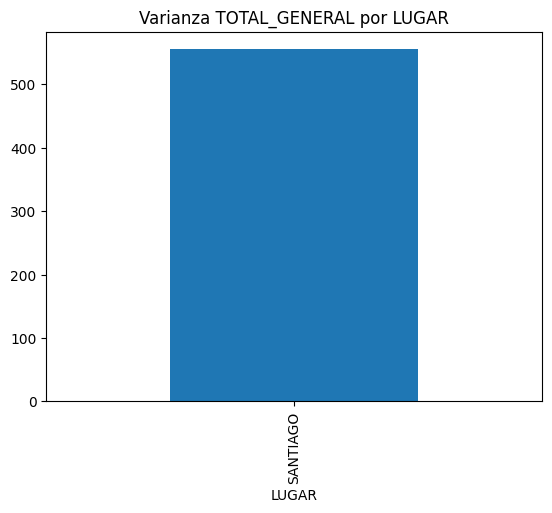

In [12]:
desechos_csv_unificado_df.groupby('LUGAR')['TOTAL_GENERAL'].std().plot(kind='bar')
plt.title('Varianza TOTAL_GENERAL por LUGAR')
plt.show()

In [13]:
duplicados = desechos_csv_unificado_df[desechos_csv_unificado_df.duplicated(subset=['MES_ANIO', 'AMS', 'TOTAL_PRIVADAS'], keep=False)]
print(duplicados)

      AMS  MECANIZADOS  URBALUZ  TOTAL_GENERAL  AYUNTAMIENTO  CONSORCIO  \
1      20         2.65       48         243.08         33.03        127   
2      22        10.17       49          51.88         35.49         36   
5      22         2.79       46         271.54         37.82        136   
6      17         2.36       42         229.09         33.43        192   
9      17         1.98       42         296.30         37.01        207   
...   ...          ...      ...            ...           ...        ...   
2028    0         0.00        0         732.99          0.00          0   
2029    0         0.00        0         883.35          0.00          0   
2030    0         0.00        0         732.93          0.00          0   
2031    0         0.00        0         659.81          0.00          0   
2032    0         0.00        0          73.58          0.00          0   

     MES_ANIO     LUGAR  TOTAL_PRIVADAS  COMLURSA  LUGAR_ST  SUMA_COMP  \
1      022025  SANTIAGO  

In [14]:
mensual = desechos_csv_unificado_df.groupby('MES_ANIO')['TOTAL_GENERAL'].sum()
print(mensual)

MES_ANIO
012018     2629.21
012020        0.00
012021        0.00
012022        0.00
012023        0.00
            ...   
122019        0.00
122020        0.00
122021        0.00
122023        0.00
122024    12241.95
Name: TOTAL_GENERAL, Length: 71, dtype: float64


#### LIMPIEZA Y VALIDACION

In [15]:
print("\n=== PASO 1: LIMPIAR TOTAL_GENERAL ===")
df_clean = desechos_csv_unificado_df.copy()
print("Dataset original:", df_clean.shape)

df_clean['TOTAL_GENERAL'] = pd.to_numeric(df_clean['TOTAL_GENERAL'], errors='coerce')

df_clean['TOTAL_GENERAL'] = df_clean.groupby(['MES_ANIO', 'LUGAR_ST'])['TOTAL_GENERAL'].transform(
    lambda x: x.fillna(x.mean())
)

global_mean = df_clean['TOTAL_GENERAL'].mean()
df_clean['TOTAL_GENERAL'].fillna(global_mean, inplace=True)

print(f"NaN TOTAL_GENERAL resueltos: {df_clean['TOTAL_GENERAL'].isna().sum()}")


=== PASO 1: LIMPIAR TOTAL_GENERAL ===
Dataset original: (2033, 13)
NaN TOTAL_GENERAL resueltos: 0


/tmp/ipykernel_729/2998986597.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TOTAL_GENERAL'].fillna(global_mean, inplace=True)


In [16]:
print("\n=== PASO 2: ELIMINAR OUTLIERS ===")
mean_total = df_clean['TOTAL_GENERAL'].mean()
std_total = df_clean['TOTAL_GENERAL'].std()
lim_inf = mean_total - 3*std_total
lim_sup = mean_total + 3*std_total

print(f"Límites: {lim_inf:.1f} - {lim_sup:.1f}")
outliers = df_clean[(df_clean['TOTAL_GENERAL'] < lim_inf) |
                   (df_clean['TOTAL_GENERAL'] > lim_sup)]
print(f"Outliers eliminados: {len(outliers)}")

df_clean = df_clean[(df_clean['TOTAL_GENERAL'] >= lim_inf) &
                   (df_clean['TOTAL_GENERAL'] <= lim_sup)].reset_index(drop=True)

print("\n=== PASO 3: DUPLICADOS ===")
antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['MES_ANIO', 'LUGAR_ST', 'AMS', 'TOTAL_PRIVADAS'])
print(f"Duplicados eliminados: {antes - len(df_clean)}")

# PASO 4: VERIFICAR CONSISTENCIA TOTAL vs SUMA
print("\n=== PASO 4: CONSISTENCIA ===")
cols_comp = ['AMS','MECANIZADOS','URBALUZ','AYUNTAMIENTO','COMLURSA','TOTAL_PRIVADAS']
df_clean['SUMA_COMP'] = df_clean[cols_comp].sum(axis=1)
df_clean['ERROR_PCT'] = abs(df_clean['TOTAL_GENERAL'] - df_clean['SUMA_COMP']) / df_clean['SUMA_COMP']

# Marcar inconsistentes (>10% error)
inconsistentes = df_clean[df_clean['ERROR_PCT'] > 0.1]
print(f"Inconsistencias (>10%): {len(inconsistentes)}")

# Opcional: imputar inconsistentes con la suma
df_clean.loc[df_clean['ERROR_PCT'] > 0.1, 'TOTAL_GENERAL'] = df_clean['SUMA_COMP']

# PASO 5: CONVERTIR A FLOAT todas las numéricas
print("\n=== PASO 5: TIPOS FLOAT ===")
cols_numericas = ['AMS','MECANIZADOS','URBALUZ','TOTAL_GENERAL','AYUNTAMIENTO',
                 'CONSORCIO','TOTAL_PRIVADAS','COMLURSA','SUMA_COMP','ERROR_PCT']
for col in cols_numericas:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Tipos después limpieza:")
print(df_clean.dtypes)

# RESULTADO FINAL
print(f"\n LIMPIEZA COMPLETADA")
print(f"Original: {1727} filas → Limpio: {len(df_clean)} filas")
print(f"Dataset limpio listo para ML: df_clean")


=== PASO 2: ELIMINAR OUTLIERS ===
Límites: -717.5 - 1549.3
Outliers eliminados: 3

=== PASO 3: DUPLICADOS ===
Duplicados eliminados: 1809

=== PASO 4: CONSISTENCIA ===
Inconsistencias (>10%): 221

=== PASO 5: TIPOS FLOAT ===
Tipos después limpieza:
AMS                 int64
MECANIZADOS       float64
URBALUZ             int64
TOTAL_GENERAL     float64
AYUNTAMIENTO      float64
CONSORCIO           int64
MES_ANIO           object
LUGAR              object
TOTAL_PRIVADAS      int64
COMLURSA            int64
LUGAR_ST            int64
SUMA_COMP         float64
ERROR_TOTAL       float64
ERROR_PCT         float64
dtype: object

 LIMPIEZA COMPLETADA
Original: 1727 filas → Limpio: 221 filas
Dataset limpio listo para ML: df_clean


In [17]:
# Métricas finales
print("\n=== VERIFICACIÓN FINAL ===")
print("Valores nulos restantes:")
print(df_clean.isnull().sum())
print("\nEstadísticas TOTAL_GENERAL:")
print(df_clean['TOTAL_GENERAL'].describe())
print("\nDistribución por MES_ANIO:")
print(df_clean['MES_ANIO'].value_counts().head(10))

df_clean.to_csv('residuos_santiago_limpio.csv', index=False)
print("✅ Guardado: residuos_santiago_limpio.csv")


=== VERIFICACIÓN FINAL ===
Valores nulos restantes:
AMS               0
MECANIZADOS       0
URBALUZ           0
TOTAL_GENERAL     0
AYUNTAMIENTO      0
CONSORCIO         0
MES_ANIO          0
LUGAR             0
TOTAL_PRIVADAS    0
COMLURSA          0
LUGAR_ST          0
SUMA_COMP         0
ERROR_TOTAL       0
ERROR_PCT         0
dtype: int64

Estadísticas TOTAL_GENERAL:
count      221.000000
mean       461.818281
std       1226.621243
min          0.000000
25%          0.000000
50%        176.710000
75%        456.450000
max      10850.760000
Name: TOTAL_GENERAL, dtype: float64

Distribución por MES_ANIO:
MES_ANIO
042025    30
052025    23
012025    21
092025    20
072025    19
062025    19
022025    18
122024     8
032025     1
052021     1
Name: count, dtype: int64
✅ Guardado: residuos_santiago_limpio.csv


#### GRAFICACION DE RESULTADOS

In [18]:
# GRAFICA 1: Evolución temporal TOTAL_GENERAL
fig1 = px.line(
    df_clean.groupby('MES_ANIO')['TOTAL_GENERAL'].mean().reset_index(),
    x='MES_ANIO',
    y='TOTAL_GENERAL',
    markers=True,
    title="Evolución Mensual Residuos Santiago (2017-2025)",
    labels={'TOTAL_GENERAL': 'Toneladas promedio', 'MES_ANIO': 'Mes/Año'}
)
fig1.update_layout(height=500, showlegend=False)
fig1.show()

In [ ]:
# GRAFICA 2: Comparación por LUGAR
fig2 = px.bar(
    df_clean.groupby('LUGAR')['TOTAL_GENERAL'].agg(['mean', 'count']).reset_index(),
    x='LUGAR',
    y='mean',
    title="Producción Promedio por Vertedero",
    text='count',
    labels={'mean': 'Toneladas promedio', 'LUGAR': 'Vertedero'}
)
fig2.update_traces(texttemplate='%{text} días<br>%{y:.0f}t', textposition='outside')
fig2.show()

In [ ]:
# GRAFICA 3: Composición por compañía
composicion = df_clean[['AMS','MECANIZADOS','URBALUZ','AYUNTAMIENTO','COMLURSA','TOTAL_PRIVADAS']].mean()
fig3 = px.pie(
    values=composicion.values,
    names=composicion.index,
    title="Composición Residuos por Recolectora (%)"
)
fig3.update_traces(textposition='inside', textinfo='percent+label')
fig3.update_layout(height=500)
fig3.show()

In [ ]:
# GRAFICA 4: Boxplot distribución + outliers
fig4 = px.box(
    df_clean,
    x='LUGAR',
    y='TOTAL_GENERAL',
    title="Distribución Diaria + Outliers",
    points="outliers",
    labels={'TOTAL_GENERAL': 'Toneladas', 'LUGAR': 'Vertedero'}
)
fig4.show()

In [ ]:
# GRAFICA 5: Heatmap varianza mensual
pivot_var = df_clean.pivot_table(values='TOTAL_GENERAL', index='LUGAR', columns='MES_ANIO', aggfunc='std')
fig5 = px.imshow(
    pivot_var.values,
    x=pivot_var.columns,
    y=pivot_var.index,
    title="Varianza Mensual por Vertedero",
    aspect="auto",
    color_continuous_scale='RdYlBu_r'
)
fig5.show()

In [ ]:
# GRAFICA 6: Scatter consistencia TOTAL vs SUMA
df_clean['SUMA_COMP'] = df_clean[['AMS','MECANIZADOS','URBALUZ','AYUNTAMIENTO','COMLURSA','TOTAL_PRIVADAS']].sum(axis=1)
fig6 = px.scatter(
    df_clean,
    x='SUMA_COMP',
    y='TOTAL_GENERAL',
    title="Consistencia: Suma Componentes vs TOTAL Reportado",
    trendline='ols',
    labels={'SUMA_COMP': 'Suma componentes', 'TOTAL_GENERAL': 'TOTAL reportado'}
)
fig6.add_hline(y=df_clean['SUMA_COMP'].mean(), line_dash="dash", line_color="red")
fig6.show()
